# Inteligência Artifical e Aprendizado de Máquina - 2026/01

**Professor:** Gabriel de Oliveira Ramos

**Alunos:** Ana Beatriz Stahl, Clara Burghardt, Diogo Fernandes, Henrique Haag

**Apresentação:** https://github.com/GalegoSonolento/Trabalho_GA_IA_e_Machine_Learning/tree/master/Video_de_apresentacao

## **1 INTRODUÇÃO - VERSÃO ALTERNATIVA**

O Problema do Caixeiro Viajante (do inglês Traveling Salesman Problem – TSP) consiste em encontrar a menor rota que permita visitar um conjunto de cidades uma única vez e retornar ao ponto de origem, minimizando o custo total (como distância ou tempo). Apesar de sua definição simples, trata-se de um problema de alta complexidade (NP-difícil), o que significa que não existem algoritmos de tempo polinomial conhecidos para encontrar a solução ótima, uma vez que o número de possíveis rotas cresce rapidamente com o aumento do número de cidades.

Esse problema possui diversas aplicações práticas. Por exemplo, empresas de entrega precisam definir a melhor ordem de visitas aos clientes para reduzir custos e tempo de deslocamento. De forma semelhante, no transporte público, rotas podem ser otimizadas para atender diferentes pontos com maior eficiência. Na indústria, o TSP também aparece no sequenciamento de tarefas, onde a ordem de execução impacta diretamente o tempo de produção.

Um exemplo simples é o de um entregador que precisa visitar várias cidades: dependendo da ordem escolhida, ele pode percorrer uma distância significativamente maior do que o necessário. O objetivo do TSP é justamente encontrar a melhor sequência de visitas para minimizar esse percurso.

Devido à dificuldade de resolver o problema de forma exata em grandes instâncias, utilizam-se abordagens heurísticas, como os Algoritmos Genéticos. Neste trabalho, será utilizado o Algoritmo Genético (AG), devido à sua capacidade de explorar eficientemente vastos espaços de busca. Ao emular mecanismos de evolução natural — como seleção, cruzamento e mutação — o AG consegue escapar de ótimos locais e encontrar soluções de alta qualidade (sub-ótimas ou ótimas) em tempo computacional viável, onde métodos de força bruta se tornam impraticáveis.


## **2 MODELAGEM**

### 2.1 CODIFICAÇÃO DOS INDIVÍDUOS

Para este projeto, foi adotada a Representação por Permutação (ou Codificação Adjacente). Nesta abordagem, cada indivíduo (cromossomo) é modelado como um vetor de números inteiros de tamanho $n$, onde cada número representa o identificador único de uma cidade.

- Estrutura: Um indivíduo $P = [c_1, c_2, ..., c_n]$ indica que o caixeiro visita a cidade $c_1$, depois $c_2$, e assim sucessivamente, até retornar de $c_n$ para $c_1$.

- Restrição de Validade: Para que o indivíduo represente uma rota válida (um ciclo hamiltoniano), o cromossomo deve obrigatoriamente conter uma permutação completa do conjunto de cidades, sem repetições ou omissões de genes.

Por exemplo, considerando um conjunto de 5 cidades identificadas pelos números {1, 2, 3, 4, 5}, um indivíduo pode ser representado como:

Indivíduo A: (1, 3, 5, 2, 4)
Indivíduo B: (4, 2, 1, 5, 3)

Cada uma dessas sequências representa uma rota diferente. No caso do Indivíduo A, o caixeiro partiria da cidade 1, seguiria para a cidade 3, depois 5, 2, 4 e, por fim, retornaria à cidade inicial.

Como exemplo prático, em um cenário de entregas, cada indivíduo representa uma possível ordem de visitas aos clientes. Diferentes indivíduos correspondem a diferentes rotas, e o algoritmo genético busca evoluir essas soluções ao longo das gerações, encontrando sequências cada vez mais eficientes.

### 2.2 FUNÇÃO OBJETIVO

A modelagem distingue o custo real da rota da sua pontuação dentro do processo evolutivo.

- Função Objetivo ($g(x)$): Corresponde ao custo total da viagem. É calculada pela soma das distâncias entre cidades consecutivas no cromossomo, incluindo o retorno à origem:$$g(x) = \sum_{i=1}^{n-1} dist(c_i, c_{i+1}) + dist(c_n, c_1)$$

- Função de Aptidão/Fitness ($f(x)$): Como o AG busca maximizar o "mérito" e o TSP é um problema de minimização de distância, aplicamos uma transformação de inversão. A aptidão de um indivíduo é definida como:$$f(x) = \frac{1}{g(x)}$$

Dessa forma, rotas com distâncias menores resultam em valores de fitness maiores, recebendo maior probabilidade de serem selecionadas para a próxima geração.

- Exemplo 1: em um cenário de entregas, a função objetivo pode representar a distância total percorrida por um entregador. Nesse caso, o objetivo é encontrar a ordem de visitas que minimize a soma das distâncias entre todos os pontos.

- Exemplo 2: em aplicações industriais, a função objetivo pode estar relacionada ao tempo de processamento ou custo de operação, onde a ordem das tarefas influencia diretamente a eficiência do sistema produtivo.

### 2.3 ANÁLISE DO ESPAÇO DE BUSCA

O espaço de busca do TSP é definido pelo conjunto de todas as permutações possíveis das cidades.

- Complexidade Combinatória: Para um problema com $n$ cidades, existem $(n-1)!$ rotas possíveis se considerarmos um ponto de partida fixo. Em casos onde a direção da rota não importa (TSP Simétrico), o espaço de busca efetivo é de $\frac{(n-1)!}{2}$.

- Complexidade da Função Objetivo: O cálculo da função objetivo (avaliação de um único indivíduo) possui complexidade $O(n)$, pois exige uma iteração simples sobre o vetor de tamanho $n$ para somar as distâncias.

- Desafio Computacional: Devido ao crescimento fatorial do espaço de busca, um aumento linear no número de cidades causa um aumento explosivo nas combinações, tornando a busca exaustiva impossível para $n > 20$. O AG mitiga isso ao avaliar apenas uma fração representativa desse espaço através das gerações.

## **3 DECISÕES DE IMPLEMENTAÇÃO**
Para atender aos requisitos de multiplicidade de operadores, as seguintes estratégias foram selecionadas:

### 3.1 OPERADORES GENÉTICOS
Deverão ser implementadas e testadas as seguintes variações para cada operador:
- **Seleção:**
  - Torneio (k=3): Seleciona aleatoriamente $k$ indivíduos e escolhe o melhor entre eles.
  - Roleta (Roulette Wheel): A probabilidade de seleção é proporcional ao fitness do indivíduo.
- **Cruzamento** (Crossover):
  - Order Crossover (OX): Preserva a ordem relativa das cidades, essencial para o TSP.
  - Cycle Crossover (CX): Garante que cada cidade na progênie venha da mesma posição de um dos pais.
- **Mutação:**
  - Swap Mutation: Troca a posição de duas cidades aleatórias.
  - Inversion Mutation: Inverte a ordem de um subsegmento da rota.
- **Estado da Arte:**
  - Edge Recombination Operator (ERO): Foca em preservar as adjacências (arestas) entre cidades, o que é biologicamente e matematicamente mais eficiente para o TSP.

### 3.2 REFINAMENTO LOCAL (ALGORITMO MEMÉTICO)
Ao final das gerações do AG, o melhor indivíduo será submetido a um algoritmo de **Hill Climbing**.
- **Estratégia:** Utilizaremos o movimento 2-opt, que remove duas arestas e as reconecta de forma diferente para eliminar cruzamentos na rota, buscando o ótimo local mais próximo.

## **4 PLANEJAMENTO DE EXPERIMENTOS**
A validação do algoritmo seguirá os seguintes parâmetros técnicos:

### 4.1 CONFIGURAÇÃO DE HIPERPARÂMETROS
- **Tamanho da População:** 100 indivíduos.
- **Taxa de Cruzamento:** Testes entre 70% e 90%.
- **Taxa de Mutação:** Testes entre 1% e 5%.
- **Critério de Parada:** O algoritmo encerrará quando a melhor solução da população não apresentar melhoria superior a $10^{-6}$ por 50 gerações consecutivas (convergência/estagnação).

### 4.2 METODOLOGIA DE AVALIAÇÃO
Instâncias: O algoritmo será testado em todas as instâncias do TSP fornecidas no Moodle.
1. **Repetições:** Devido à natureza estocástica, cada configuração será executada 30 vezes para extração de média e desvio padrão.
2. **Métricas:** Serão gerados gráficos de evolução da aptidão média e máxima por geração para visualizar a velocidade de convergência e a eficácia do Hill Climbing final.

### 4.3 Matriz de cenários de teste
Cenário  | Seleção | Cruzamento (Crossover)  | Mutação    | Refinamento Local
---------|---------|-------------------------|------------|------------------
01       | Torneio | Order Crossover (OX)    | Swap       | Não
02       | Torneio | Order Crossover (OX)    | Inversion  | Não
03       | Torneio | Cycle Crossover (CX)    | Swap       | Não
04       | Torneio | Cycle Crossover (CX)    | Inversion  | Não
05       | Roleta  | Order Crossover (OX)    | Swap       | Não
06       | Roleta  | Order Crossover (OX)    | Inversion  | Não
07       | Roleta  | Cycle Crossover (CX)    | Swap       | Não
08       | Roleta  | Cycle Crossover (CX)    | Inversion  | Não
09 (SOTA)| Torneio*| Edge Recombination (ERO)| Inversion\*| Sim (Hill Climbing)

**(\*) Nota:** Operadores de Seleção e Mutação serão definidos com base nos melhores resultados observados nos cenários de 01 a 08.

## **5 IMPLEMENTAÇÃO**

Esta seção apresenta a implementação completa do Algoritmo Genético para o TSP, seguindo as decisões de modelagem e operadores definidos nas seções anteriores. A implementação é estruturada em módulos independentes: leitura das instâncias, representação dos indivíduos, função de fitness, operadores genéticos (seleção, cruzamento e mutação), refinamento local por Hill Climbing 2-opt e o loop principal do AG.

# New Section

### 5.1 Upload e Extração das Instâncias

Para garantir portabilidade e independência de caminhos locais, o notebook realiza o upload manual do arquivo compactado e sua extração diretamente no ambiente de execução. O processo de extração preserva a organização original dos arquivos, permitindo que as instâncias sejam acessadas posteriormente pelos caminhos relativos definidos no código.

In [10]:
from google.colab import files
import zipfile

# Upload do arquivo ZIP com as instâncias
uploaded = files.upload()
zip_name = list(uploaded.keys())[0]

# Extrai mantendo a estrutura original
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall()

print("Arquivos extraídos com sucesso!")

Saving instances.zip to instances.zip
Arquivos extraídos com sucesso!


### 5.1 Leitura das Instâncias

Cada arquivo de instância TSP contém linhas no formato `id x y`, onde `id` é o identificador da cidade e `x`, `y` são suas coordenadas. A função `load_tsp` lê o arquivo e retorna uma lista de tuplas `(id, x, y)`. O custo entre duas cidades é a distância Euclidiana, calculada por `euclidean_distance`.

In [11]:
import math
import random

def load_tsp(filepath):
    """Lê uma instância TSP no formato 'id x y' e retorna lista de (id, x, y)."""
    cities = []
    with open(filepath) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 3:
                node_id, x, y = int(parts[0]), float(parts[1]), float(parts[2])
                cities.append((node_id, x, y))
    return cities

def euclidean_distance(c1, c2):
    """Distância Euclidiana entre dois nós (id, x, y)."""
    return math.sqrt((c1[1] - c2[1])**2 + (c1[2] - c2[2])**2)

def build_distance_matrix(cities):
    """Pré-computa a matriz de distâncias entre todas as cidades."""
    n = len(cities)
    dist = [[0.0] * n for _ in range(n)]
    for i in range(n):
        for j in range(i + 1, n):
            d = euclidean_distance(cities[i], cities[j])
            dist[i][j] = d
            dist[j][i] = d
    return dist

# Carregamento das quatro instâncias
instances = {
    'berlin52': load_tsp('instances/TSP/berlin52.tsp'),
    'eil51':    load_tsp('instances/TSP/eil51.tsp'),
    'pr152':    load_tsp('instances/TSP/pr152.tsp'),
    'rat99':    load_tsp('instances/TSP/rat99.tsp'),
}

# Verificação: exibir as 3 primeiras cidades de cada instância
for name, cities in instances.items():
    print(f'{name}: {len(cities)} cidades  |  primeiras 3: {cities[:3]}')

berlin52: 52 cidades  |  primeiras 3: [(1, 565.0, 575.0), (2, 25.0, 185.0), (3, 345.0, 750.0)]
eil51: 51 cidades  |  primeiras 3: [(1, 37.0, 52.0), (2, 49.0, 49.0), (3, 52.0, 64.0)]
pr152: 152 cidades  |  primeiras 3: [(1, 2100.0, 1850.0), (2, 2100.0, 3000.0), (3, 2100.0, 4400.0)]
rat99: 99 cidades  |  primeiras 3: [(1, 6.0, 4.0), (2, 15.0, 15.0), (3, 24.0, 18.0)]


### 5.2 Representação e Função de Fitness

Cada indivíduo é uma lista de índices inteiros `[0, 1, ..., n-1]` representando a ordem de visita das cidades (permutação). A função objetivo $g(x)$ calcula o custo total da rota; a função de fitness $f(x) = 1 / g(x)$ inverte o custo para que o AG maximize a aptidão dos indivíduos de menor distância.

In [12]:
class EvaluateTSP:
    """
    Avalia uma rota (permutação de índices) calculando a distância total da viagem.
    A função objetivo g(x) é a soma das distâncias consecutivas + retorno à origem.
    A função de fitness f(x) = 1 / g(x) — quanto menor a distância, maior o fitness.
    """
    def __init__(self, dist_matrix):
        self.dist = dist_matrix

    def route_cost(self, route):
        """Custo total da rota: g(x)."""
        total = sum(self.dist[route[i]][route[i + 1]] for i in range(len(route) - 1))
        total += self.dist[route[-1]][route[0]]  # retorno à cidade de origem
        return total

    def __call__(self, route):
        """Fitness f(x) = 1 / g(x)."""
        return 1.0 / self.route_cost(route)


def init_population(pop_size, n_cities):
    """Gera uma população de `pop_size` permutações aleatórias de `n_cities` índices."""
    return [random.sample(range(n_cities), n_cities) for _ in range(pop_size)]


# Demonstração com berlin52
cities = instances['berlin52']
dist_matrix = build_distance_matrix(cities)
fn_fitness = EvaluateTSP(dist_matrix)

sample_route = list(range(len(cities)))
print(f'Custo da rota identidade (berlin52): {fn_fitness.route_cost(sample_route):.2f}')
print(f'Fitness correspondente:              {fn_fitness(sample_route):.8f}')

Custo da rota identidade (berlin52): 22205.62
Fitness correspondente:              0.00004503


### 5.3 Operadores de Seleção

Dois operadores foram implementados conforme definido na Seção 3.

**Seleção por Torneio (k=3):** Amostra aleatoriamente $k$ indivíduos da população e retorna o de maior fitness. Introduz pressão seletiva controlada sem depender da escala absoluta do fitness.

**Seleção por Roleta:** Atribui a cada indivíduo uma probabilidade de seleção proporcional ao seu fitness. Indivíduos mais aptos têm maior chance de ser escolhidos.

In [13]:
def select_tournament(population, fn_fitness, k=3):
    """
    Seleção por Torneio: amostra k indivíduos aleatoriamente e retorna o de maior fitness.
    """
    competitors = random.sample(population, k)
    return max(competitors, key=fn_fitness)


def select_roulette(population, fn_fitness):
    """
    Seleção por Roleta: probabilidade de seleção proporcional ao fitness.
    Utiliza soma acumulada e busca binária para eficiência.
    """
    import bisect
    fitnesses = [fn_fitness(ind) for ind in population]
    cumulative = []
    total = 0.0
    for f in fitnesses:
        total += f
        cumulative.append(total)
    pick = random.uniform(0, total)
    idx = bisect.bisect(cumulative, pick)
    # garante índice válido caso pick == total
    return population[min(idx, len(population) - 1)]

### 5.4 Operadores de Cruzamento

Três operadores foram implementados para gerar filhos a partir de dois pais mantendo a validade da permutação (sem cidades repetidas ou ausentes).

**Order Crossover (OX):** Copia um segmento contíguo do pai P1 para o filho. As posições restantes são preenchidas, em ordem, com as cidades do pai P2 que ainda não constam no filho.

**Cycle Crossover (CX):** Identifica ciclos de posições que vinculam os pais. As posições pertencentes a ciclos de índice ímpar vêm de P1; as de índice par vêm de P2, preservando o mapeamento posicional.

**Edge Recombination Operator (ERO) — Estado da Arte:** Constrói uma tabela de adjacências listando os vizinhos de cada cidade em ambos os pais. O filho é construído cidade a cidade: a cada passo, escolhe-se o vizinho com menos adjacências restantes (heurística gulosa), priorizando a preservação de arestas existentes nas rotas parentais.

In [14]:
def crossover_ox(p1, p2):
    """
    Order Crossover (OX): copia segmento [i1, i2] de p1; preenche restante
    com as cidades de p2 na ordem em que aparecem, pulando duplicatas.
    """
    n = len(p1)
    i1, i2 = sorted(random.sample(range(n), 2))
    segment = p1[i1:i2 + 1]
    remaining = [c for c in p2 if c not in segment]
    return remaining[:i1] + segment + remaining[i1:]


def crossover_cx(p1, p2):
    """
    Cycle Crossover (CX): identifica ciclos de posições entre os pais.
    Ciclos de índice par herdam de p1; ciclos de índice ímpar herdam de p2.
    """
    n = len(p1)
    child = [None] * n
    visited = [False] * n
    cycle_index = 0
    for start in range(n):
        if visited[start]:
            continue
        # percorre o ciclo
        pos = start
        while not visited[pos]:
            visited[pos] = True
            child[pos] = p1[pos] if cycle_index % 2 == 0 else p2[pos]
            pos = p1.index(p2[pos])
        cycle_index += 1
    return child


def crossover_ero(p1, p2):
    """
    Edge Recombination Operator (ERO): preserva as adjacências (arestas)
    de ambos os pais ao construir o filho.
    Referência: Whitley et al. (1989), "Scheduling Problems and Traveling Salesmen".
    """
    n = len(p1)

    # Monta tabela de adjacências: para cada cidade, lista seus vizinhos em p1 e p2
    adj = {c: set() for c in p1}
    for route in (p1, p2):
        for i in range(n):
            prev_c = route[(i - 1) % n]
            next_c = route[(i + 1) % n]
            adj[route[i]].add(prev_c)
            adj[route[i]].add(next_c)

    child = []
    # Cidade inicial: a primeira de p1
    current = p1[0]
    remaining = set(p1)

    while remaining:
        child.append(current)
        remaining.discard(current)
        # Remove current da lista de adjacências dos vizinhos
        for neighbors in adj.values():
            neighbors.discard(current)

        if not remaining:
            break

        # Escolhe o vizinho de current com menor lista de adjacências;
        # em caso de empate, escolhe aleatoriamente; sem vizinhos: escolhe aleatório
        neighbors = adj[current] & remaining
        if neighbors:
            current = min(neighbors, key=lambda c: len(adj[c]))
        else:
            current = random.choice(list(remaining))

    return child

### 5.5 Operadores de Mutação

**Swap Mutation:** Seleciona dois índices aleatórios da rota e troca as cidades nessas posições. Operação simples e com baixo impacto estrutural.

**Inversion Mutation:** Seleciona um subsegmento aleatório e inverte sua ordem. Ao reverter um trecho da rota, o operador pode eliminar cruzamentos de arestas, produzindo melhorias estruturalmente mais significativas que o swap.

In [15]:
def mutate_swap(route, pmut):
    """
    Swap Mutation: com probabilidade pmut, troca duas posições aleatórias da rota.
    """
    if random.random() >= pmut:
        return route
    n = len(route)
    i, j = random.sample(range(n), 2)
    route = route[:]
    route[i], route[j] = route[j], route[i]
    return route


def mutate_inversion(route, pmut):
    """
    Inversion Mutation: com probabilidade pmut, inverte um subsegmento aleatório da rota.
    """
    if random.random() >= pmut:
        return route
    n = len(route)
    i, j = sorted(random.sample(range(n), 2))
    route = route[:]
    route[i:j + 1] = route[i:j + 1][::-1]
    return route

### 5.6 Refinamento Local — Hill Climbing 2-opt

Ao final das gerações, o melhor indivíduo é submetido ao algoritmo Hill Climbing com movimento 2-opt. O movimento 2-opt remove duas arestas não-adjacentes da rota e as reconecta de forma alternativa, revertendo o subsegmento entre elas. Esse procedimento é repetido até que nenhuma troca produza melhoria, caracterizando um ótimo local 2-opt.

In [16]:
def hill_climbing_2opt(route, fn_fitness):
    """
    Hill Climbing com movimento 2-opt para o TSP.
    Testa todas as trocas de pares de arestas (i, j); aceita a primeira que
    melhora o fitness. Repete até não haver mais melhoria (ótimo local 2-opt).
    """
    n = len(route)
    improved = True
    current = route[:]
    while improved:
        improved = False
        for i in range(1, n - 1):
            for j in range(i + 1, n):
                # Reverte o segmento [i, j] — equivale a remover as arestas
                # (i-1, i) e (j, j+1) e reconectar de forma cruzada
                candidate = current[:i] + current[i:j + 1][::-1] + current[j + 1:]
                if fn_fitness(candidate) > fn_fitness(current):
                    current = candidate
                    improved = True
    return current

### 5.7 Loop Principal do Algoritmo Genético

A função `genetic_algorithm_tsp` reúne todos os componentes. Recebe os operadores como parâmetros para permitir a execução dos 9 cenários da Seção 4 sem duplicar código. O critério de parada por estagnação encerra o algoritmo quando a melhor distância não melhora mais do que $10^{-6}$ por `stagnation_limit` gerações consecutivas. A função retorna o melhor indivíduo encontrado ao final das gerações, e opcionalmente aplica o Hill Climbing 2-opt.

In [17]:
def genetic_algorithm_tsp(
    cities,
    fn_select,       # função de seleção: select_tournament ou select_roulette
    fn_crossover,    # operador de cruzamento: crossover_ox, crossover_cx ou crossover_ero
    fn_mutate,       # operador de mutação: mutate_swap ou mutate_inversion
    pop_size=100,
    pcross=0.8,
    pmut=0.02,
    stagnation_limit=50, # Gerações sem melhoria significativa para o critério de parada
    apply_local_search=False,
    verbose=False,
):
    """
    Algoritmo Genético para o TSP.

    Parâmetros:
        cities            : lista de (id, x, y)
        fn_select         : operador de seleção
        fn_crossover      : operador de cruzamento
        fn_mutate         : operador de mutação
        pop_size          : tamanho da população
        pcross            : taxa de cruzamento
        pmut              : taxa de mutação por gene
        stagnation_limit  : gerações sem melhoria para critério de parada
        apply_local_search: se True, aplica Hill Climbing 2-opt no melhor ao final
        verbose           : se True, imprime progresso a cada geração

    Retorna:
        best_route        : melhor rota encontrada (lista de índices)
        best_cost         : custo correspondente
        history           : lista com (melhor_custo, custo_médio) por geração
    """
    import sys

    n = len(cities)
    dist_matrix = build_distance_matrix(cities)
    fn_fitness = EvaluateTSP(dist_matrix)

    population = init_population(pop_size, n)
    best_route = max(population, key=fn_fitness)
    best_cost = fn_fitness.route_cost(best_route)

    history = []
    stagnation_count = 0
    gen = 0

    while stagnation_count < stagnation_limit:
        new_population = []

        for _ in range(pop_size):
            p1 = fn_select(population, fn_fitness)
            p2 = fn_select(population, fn_fitness)

            # Cruzamento com probabilidade pcross; caso contrário, copia o pai
            if random.random() < pcross:
                child = fn_crossover(p1, p2)
            else:
                child = p1[:]

            child = fn_mutate(child, pmut)
            new_population.append(child)

        population = new_population
        gen += 1

        # Atualiza o melhor e registra histórico
        gen_best = max(population, key=fn_fitness)
        gen_best_cost = fn_fitness.route_cost(gen_best)
        gen_avg_cost = sum(fn_fitness.route_cost(ind) for ind in population) / pop_size
        history.append((gen_best_cost, gen_avg_cost))

        # Critério de parada por estagnação (melhoria < 1e-6)
        if best_cost - gen_best_cost > 1e-6:
            best_route = gen_best
            best_cost = gen_best_cost
            stagnation_count = 0
        else:
            stagnation_count += 1

        if verbose:
            bar_len = 20
            filled = int(bar_len * (1 - stagnation_count / stagnation_limit))
            bar = '█' * filled + '░' * (bar_len - filled)
            sys.stdout.write(
                f'\rGen {gen:>4}  |  melhor: {best_cost:>10.2f}'
                f'  |  média: {gen_avg_cost:>10.2f}'
                f'  |  estagnação: [{bar}] {stagnation_count}/{stagnation_limit}'
            )
            sys.stdout.flush()

    if verbose:
        print()  # nova linha ao finalizar

    # Refinamento local opcional no melhor indivíduo
    if apply_local_search:
        if verbose:
            print('Aplicando Hill Climbing 2-opt...')
        best_route = hill_climbing_2opt(best_route, fn_fitness)
        best_cost = fn_fitness.route_cost(best_route)
        if verbose:
            print(f'Custo após 2-opt: {best_cost:.2f}')

    return best_route, best_cost, history

### 5.8 Verificação de Sanidade

Para confirmar que toda a implementação está integrada e funcionando corretamente, executamos uma única rodada do AG na instância `eil51` (51 cidades, ótimo conhecido: 426) usando o Cenário 01 (Torneio + OX + Swap, sem refinamento local). O objetivo aqui é apenas verificar que o código executa sem erros e produz resultados razoáveis.

In [18]:
# Verificação de sanidade — Cenário 01: Torneio + OX + Swap, sem refinamento local
random.seed(42)

best_route, best_cost, history = genetic_algorithm_tsp(
    cities=instances['eil51'],
    fn_select=select_tournament,
    fn_crossover=crossover_ox,
    fn_mutate=mutate_swap,
    pop_size=100,
    pcross=0.8,
    pmut=0.02,
    stagnation_limit=50,
    apply_local_search=False,
    verbose=True,
)

print(f'\nMelhor custo encontrado: {best_cost:.2f}  (ótimo conhecido: 426)')
print(f'Gerações executadas:      {len(history)}')

Gen  235  |  melhor:     704.94  |  média:     708.21  |  estagnação: [░░░░░░░░░░░░░░░░░░░░] 50/50

Melhor custo encontrado: 704.94  (ótimo conhecido: 426)
Gerações executadas:      235


## **6 EXPERIMENTAÇÃO**

 Executar experimentos em TODAS AS INSTÂNCIAS do problema escolhido para avaliar
o desempenho do algoritmo. Devem ser identificadas as melhores configurações de hiperparâmetros do
algoritmo, como número de repetições, taxa de mutação, etc. A identificação das melhores configurações
deve ser feita através da comparação entre diferentes conjuntos de experimentos. Gráficos deverão ser
utilizados para mostrar a evolução da aptidão média e máxima dos indivíduos ao longo das gerações.


In [19]:
import numpy as np

def run_experiments(instances, scenarios, runs=30, stagnation_limit=50):
    """
    Executa experimentos para todos os cenários e instâncias.

    Retorna:
        results[instancia][cenario] = {
            'best': [],
            'mean_history': [],
            'best_history': []
        }
    """
    results = {}

    for inst_name, cities in instances.items():
        print(f"\n=== Instância: {inst_name} ===")
        results[inst_name] = {}

        for scen_name, scen in scenarios.items():
            print(f"Rodando cenário {scen_name}...")

            best_costs = []
            histories = []

            for r in range(runs):
                best_route, best_cost, history = genetic_algorithm_tsp(
                    cities=cities,
                    fn_select=scen['select'],
                    fn_crossover=scen['crossover'],
                    fn_mutate=scen['mutate'],
                    pop_size=100,
                    pcross=0.8,
                    pmut=0.02,
                    stagnation_limit=stagnation_limit,
                    apply_local_search=scen['local_search']
                )

                best_costs.append(best_cost)
                histories.append(history)

            # Alinha históricos (corta no menor tamanho)
            min_len = min(len(h) for h in histories)
            histories = [h[:min_len] for h in histories]

            # separa best e mean por geração
            best_per_gen = np.mean([[h[i][0] for i in range(min_len)] for h in histories], axis=0)
            mean_per_gen = np.mean([[h[i][1] for i in range(min_len)] for h in histories], axis=0)

            results[inst_name][scen_name] = {
                'best_costs': best_costs,
                'mean_best': np.mean(best_costs),
                'std_best': np.std(best_costs),
                'best_history': best_per_gen,
                'mean_history': mean_per_gen
            }

    return results

In [20]:
SCENARIOS = {
    "C1": {"select": select_tournament, "crossover": crossover_ox, "mutate": mutate_swap, "local_search": False},
    "C2": {"select": select_tournament, "crossover": crossover_ox, "mutate": mutate_inversion, "local_search": False},
    "C3": {"select": select_tournament, "crossover": crossover_cx, "mutate": mutate_swap, "local_search": False},
    "C4": {"select": select_tournament, "crossover": crossover_cx, "mutate": mutate_inversion, "local_search": False},
    "C5": {"select": select_roulette, "crossover": crossover_ox, "mutate": mutate_swap, "local_search": False},
    "C6": {"select": select_roulette, "crossover": crossover_ox, "mutate": mutate_inversion, "local_search": False},
    "C7": {"select": select_roulette, "crossover": crossover_cx, "mutate": mutate_swap, "local_search": False},
    "C8": {"select": select_roulette, "crossover": crossover_cx, "mutate": mutate_inversion, "local_search": False},
    "C9": {"select": select_tournament, "crossover": crossover_ero, "mutate": mutate_inversion, "local_search": True} # SOTA: Torneio + ERO + Inversion + Hill Climbing
}

In [21]:
import matplotlib.pyplot as plt

def plot_convergence(results, instance_name, scenario_name):
    data = results[instance_name][scenario_name]

    # Convert costs to fitness for plotting
    best_fitness_history = 1 / data['best_history']
    mean_fitness_history = 1 / data['mean_history']

    plt.figure(figsize=(10, 6))
    plt.plot(best_fitness_history, label='Melhor Aptidão')
    plt.plot(mean_fitness_history, label='Média Aptidão')

    plt.title(f"Evolução da Aptidão: {instance_name} - {scenario_name}")
    plt.xlabel("Gerações")
    plt.ylabel("Aptidão (1/Custo)")
    plt.legend()
    plt.grid(True)

    plt.show()

In [22]:
def print_summary(results):
    for inst in results:
        print(f"\n=== {inst} ===")
        for scen in results[inst]:
            data = results[inst][scen]
            print(f"{scen} | mean={data['mean_best']:.2f} | std={data['std_best']:.2f}")

In [24]:
results = run_experiments(instances, SCENARIOS, runs=30, stagnation_limit=50)


=== Instância: berlin52 ===
Rodando cenário C1...
Rodando cenário C2...
Rodando cenário C3...
Rodando cenário C4...
Rodando cenário C5...
Rodando cenário C6...
Rodando cenário C7...
Rodando cenário C8...
Rodando cenário C9...

=== Instância: eil51 ===
Rodando cenário C1...
Rodando cenário C2...
Rodando cenário C3...
Rodando cenário C4...
Rodando cenário C5...
Rodando cenário C6...
Rodando cenário C7...
Rodando cenário C8...
Rodando cenário C9...

=== Instância: pr152 ===
Rodando cenário C1...
Rodando cenário C2...
Rodando cenário C3...
Rodando cenário C4...
Rodando cenário C5...
Rodando cenário C6...
Rodando cenário C7...
Rodando cenário C8...
Rodando cenário C9...

=== Instância: rat99 ===
Rodando cenário C1...
Rodando cenário C2...
Rodando cenário C3...
Rodando cenário C4...
Rodando cenário C5...
Rodando cenário C6...
Rodando cenário C7...
Rodando cenário C8...
Rodando cenário C9...



=== berlin52 ===
C1 | mean=12024.56 | std=722.05
C2 | mean=10187.84 | std=735.45
C3 | mean=13908.93 | std=1479.73
C4 | mean=18277.74 | std=1333.58
C5 | mean=23033.21 | std=618.63
C6 | mean=23028.70 | std=473.51
C7 | mean=22547.06 | std=1291.48
C8 | mean=21455.59 | std=1925.22
C9 | mean=8301.40 | std=260.71

=== eil51 ===
C1 | mean=708.01 | std=45.06
C2 | mean=576.81 | std=38.56
C3 | mean=758.93 | std=63.33
C4 | mean=1017.57 | std=75.22
C5 | mean=1278.30 | std=37.64
C6 | mean=1280.38 | std=34.84
C7 | mean=1258.10 | std=69.28
C8 | mean=1221.30 | std=87.47
C9 | mean=461.20 | std=11.73

=== pr152 ===
C1 | mean=363907.94 | std=36396.46
C2 | mean=213420.50 | std=37839.49
C3 | mean=421386.85 | std=40046.09
C4 | mean=743493.97 | std=32987.30
C5 | mean=895751.95 | std=13141.84
C6 | mean=898997.51 | std=10871.85
C7 | mean=875122.43 | std=23044.94
C8 | mean=886876.65 | std=25965.60
C9 | mean=77945.26 | std=1075.08

=== rat99 ===
C1 | mean=3037.74 | std=231.28
C2 | mean=2234.32 | std=216.36
C3 | 

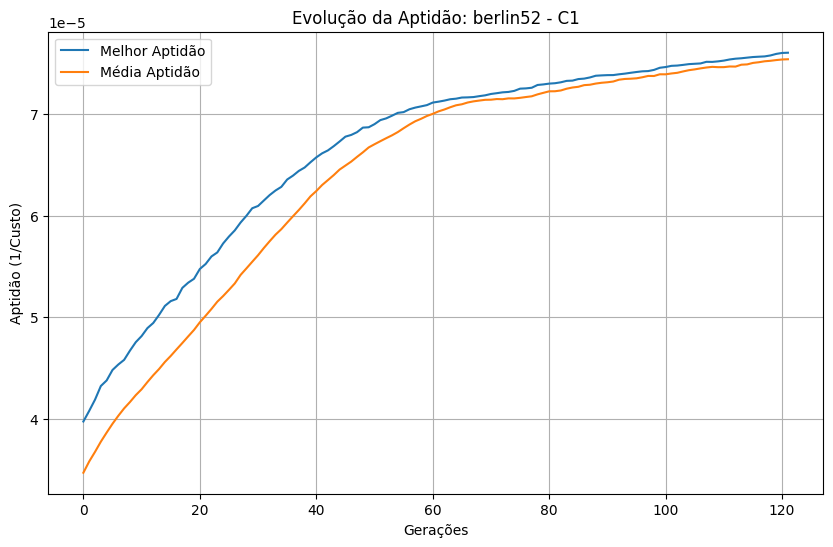

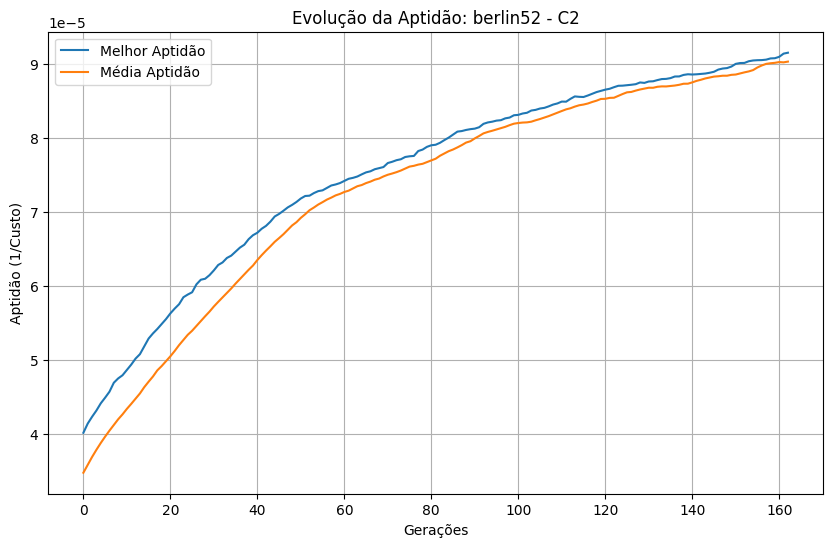

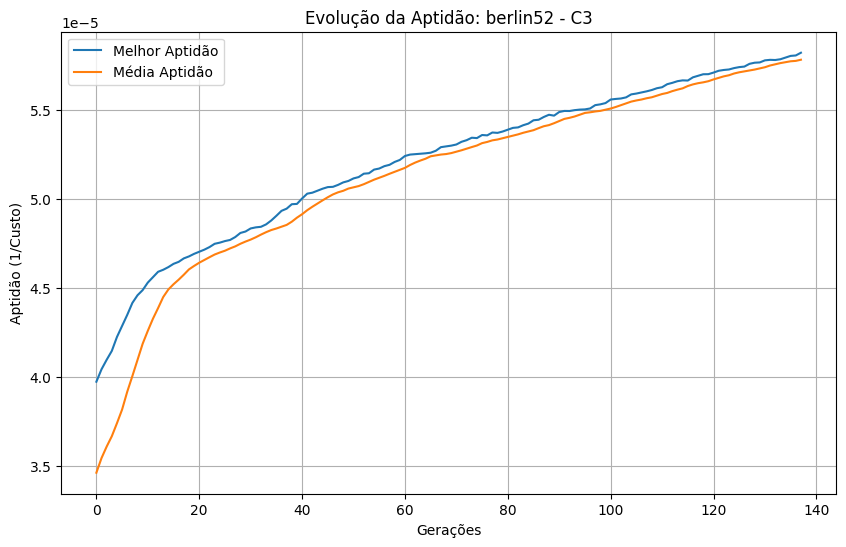

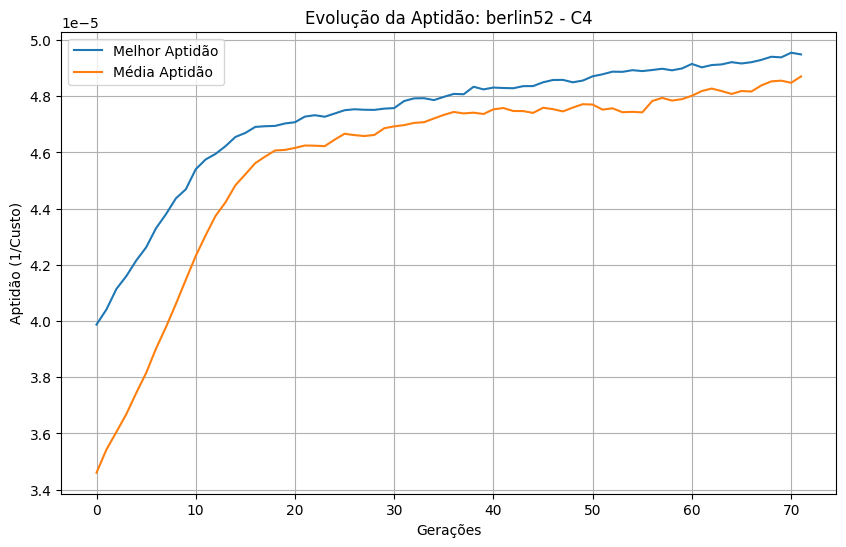

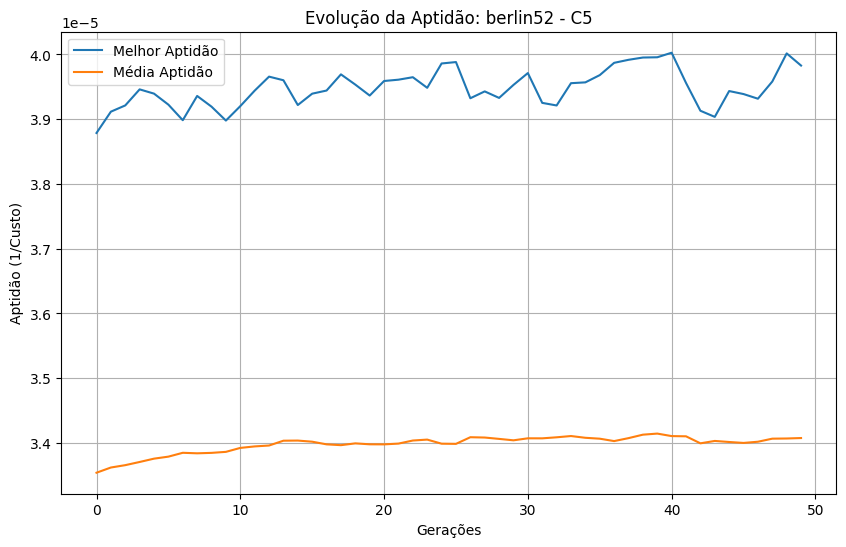

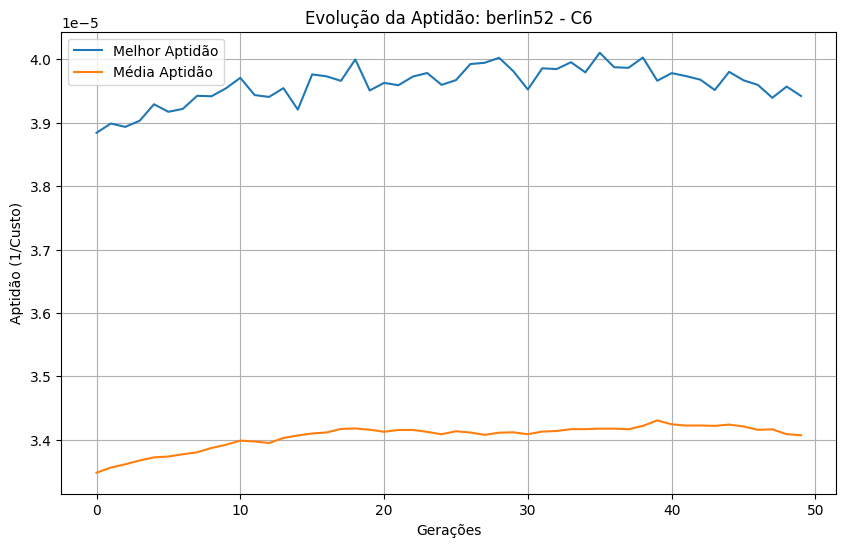

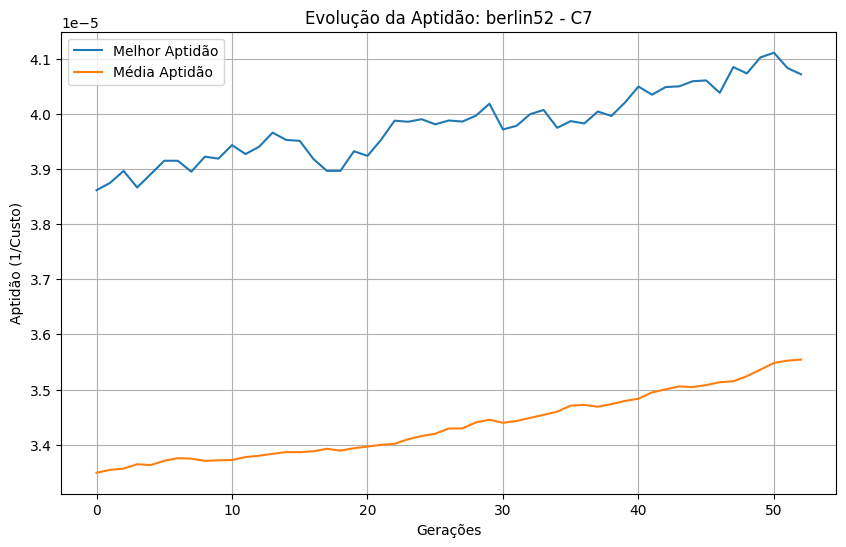

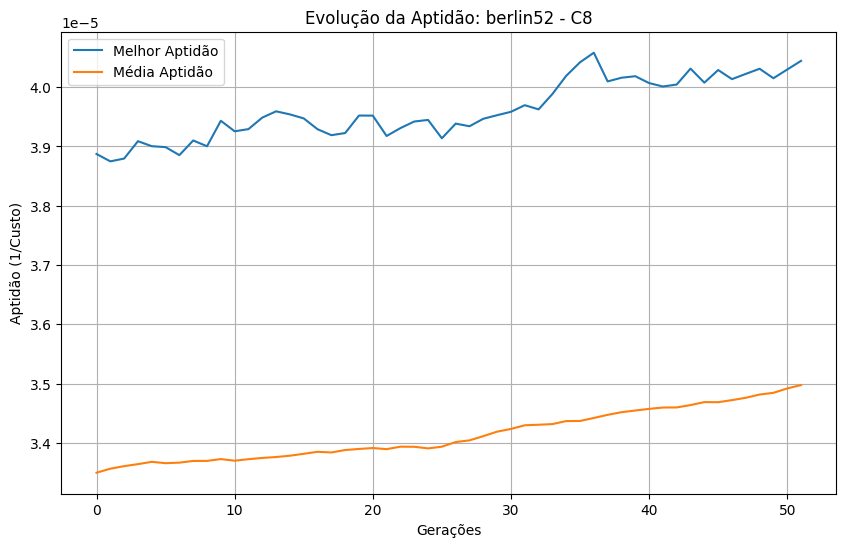

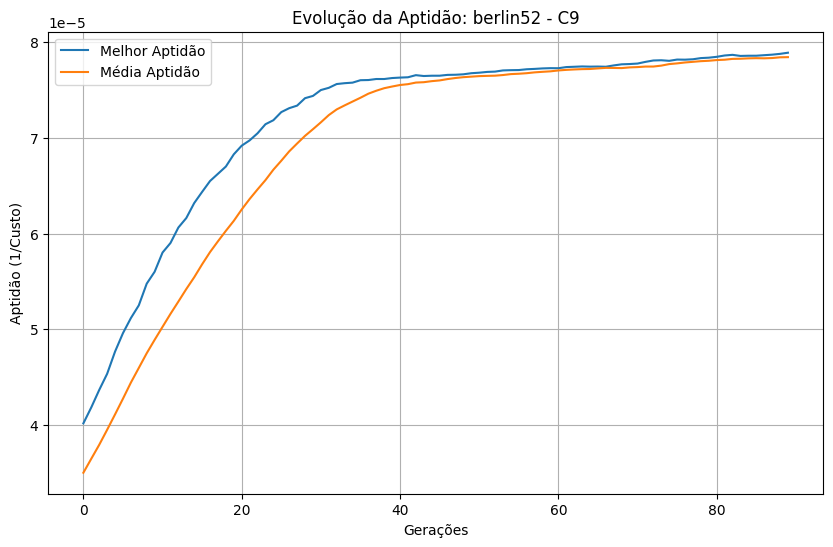

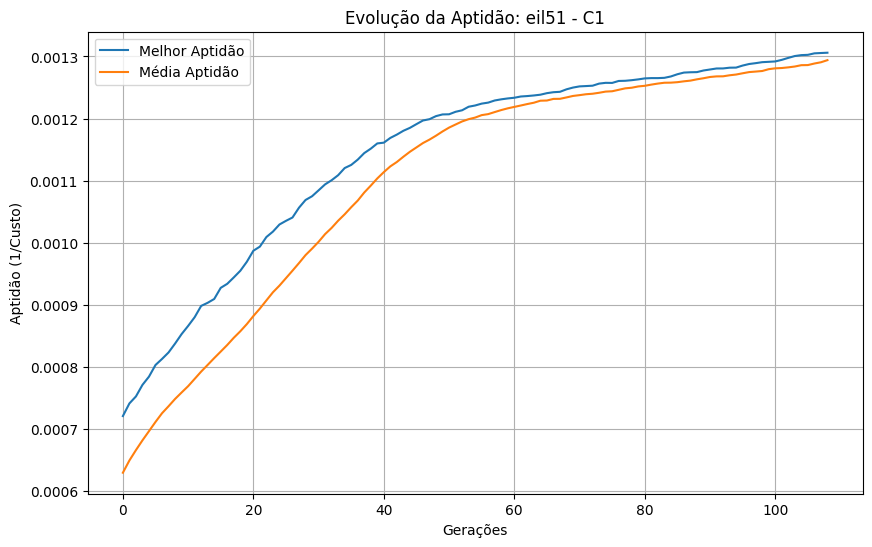

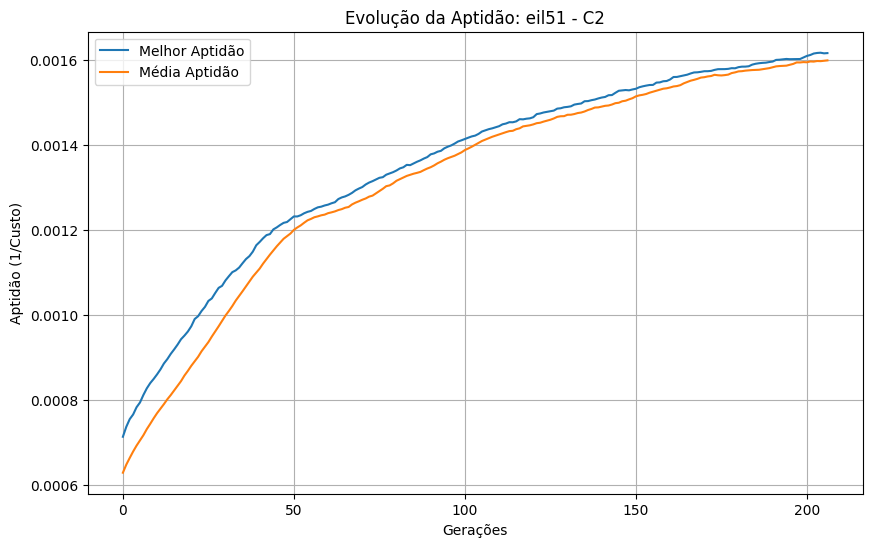

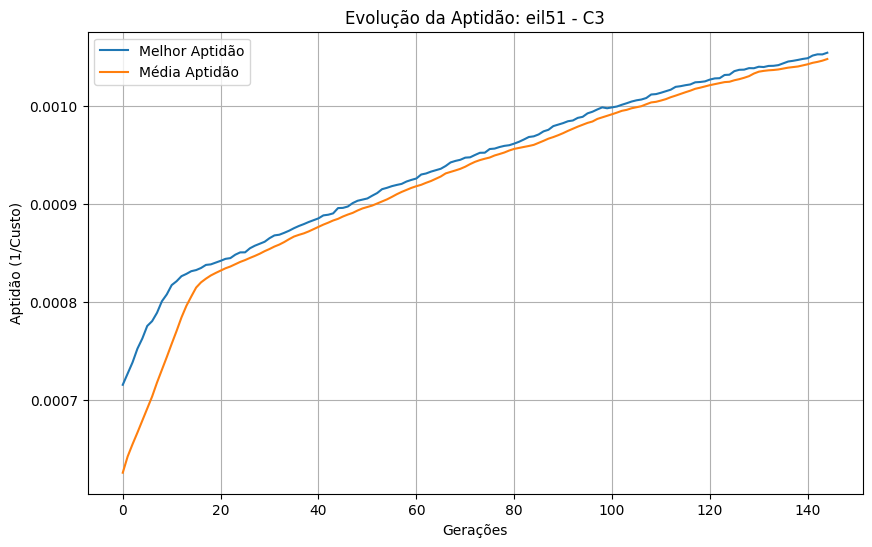

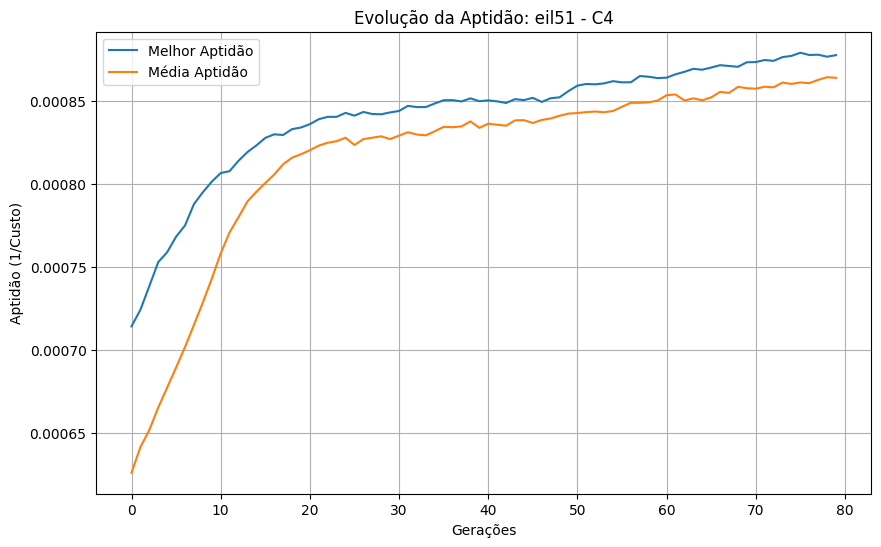

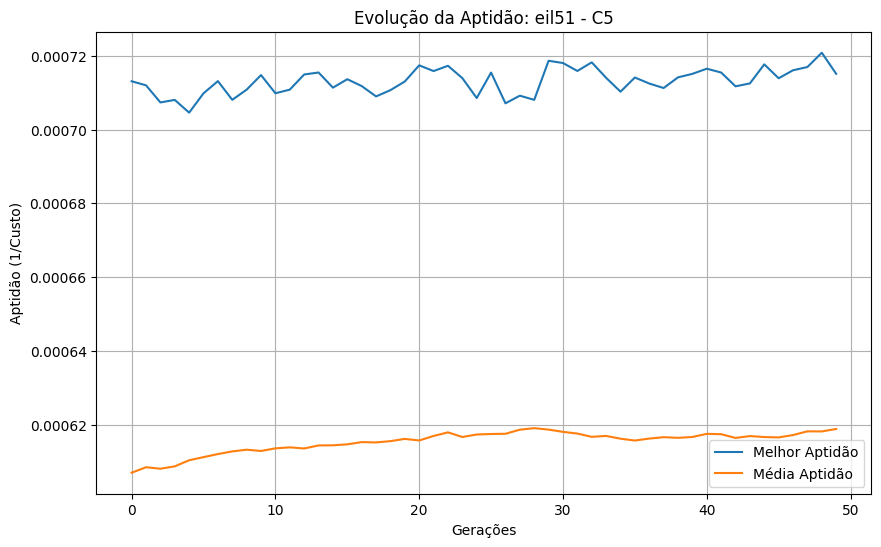

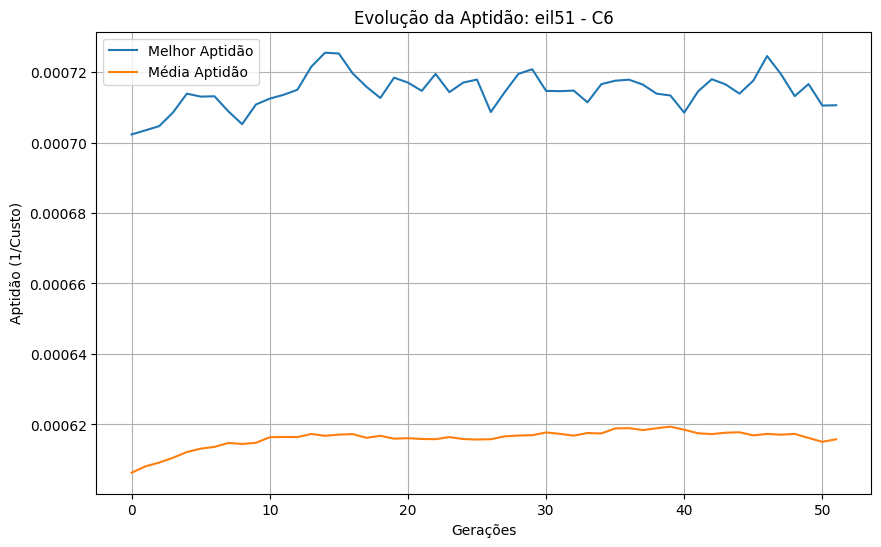

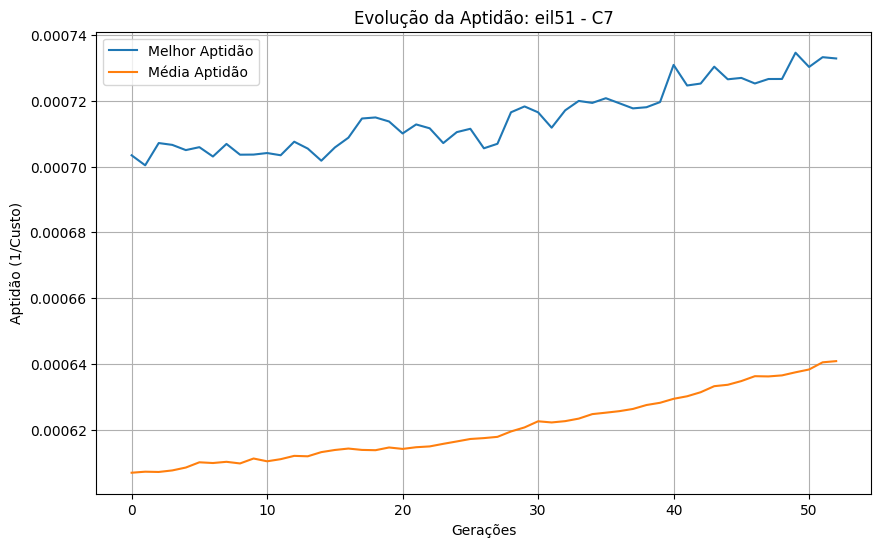

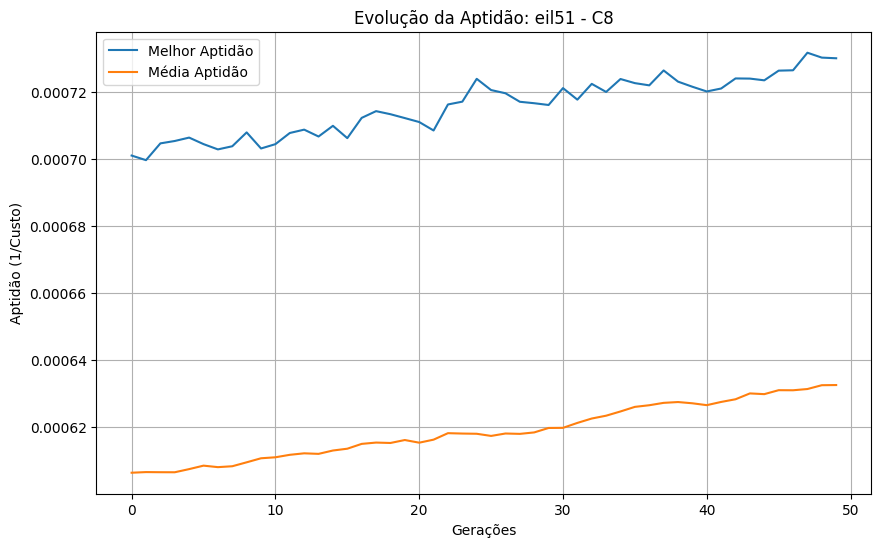

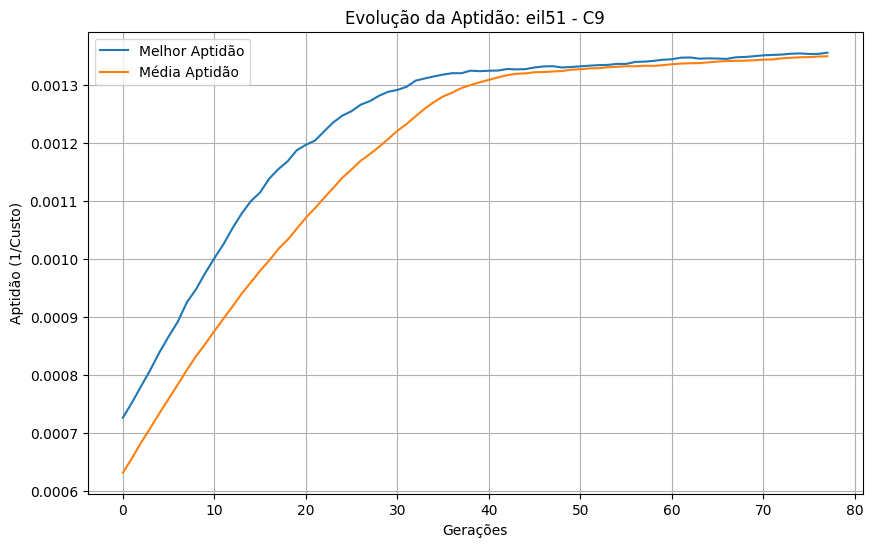

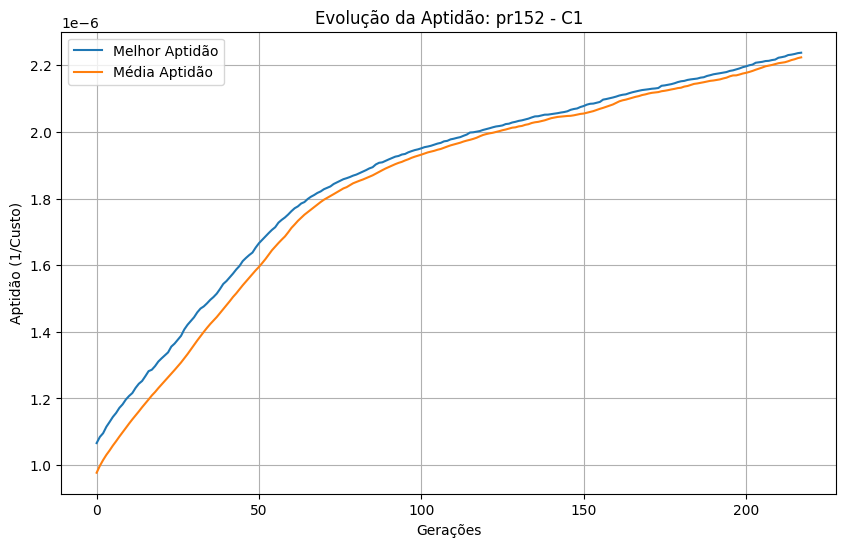

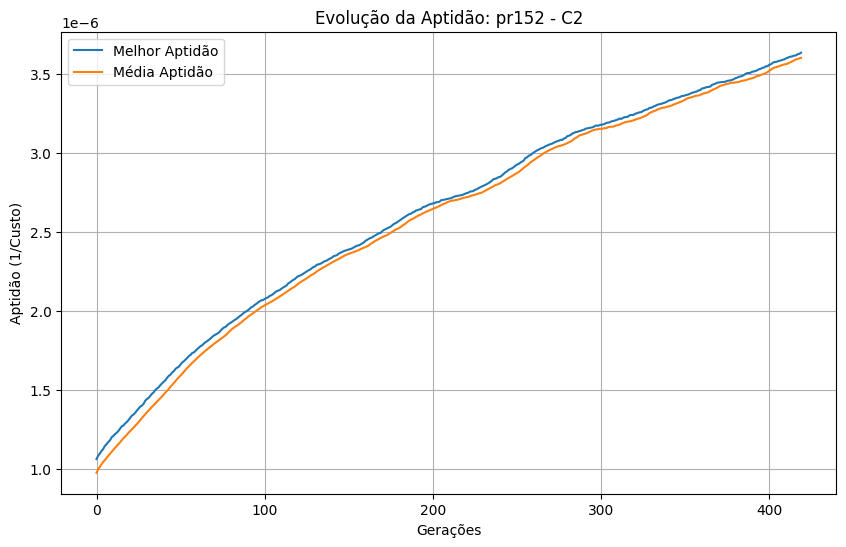

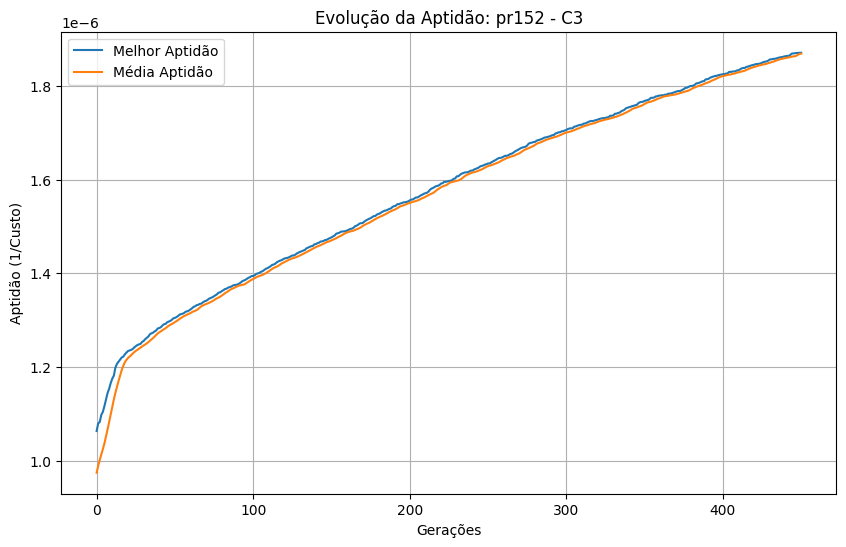

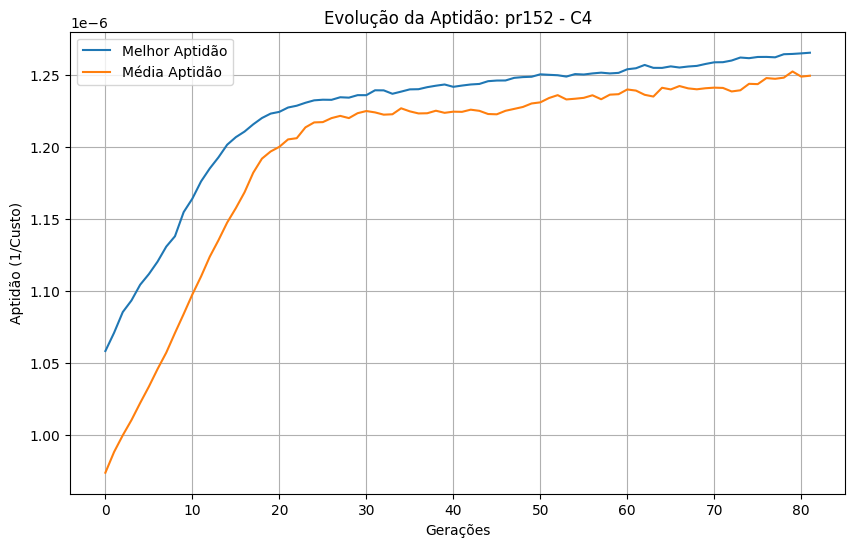

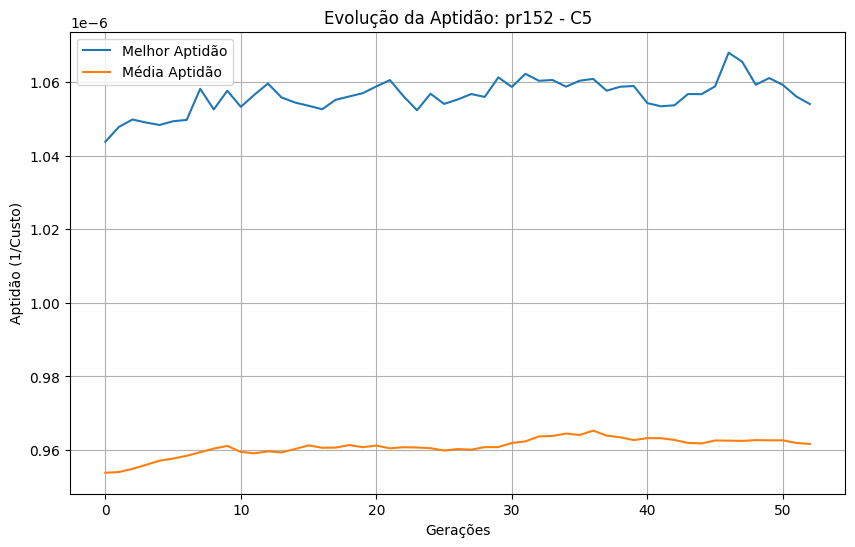

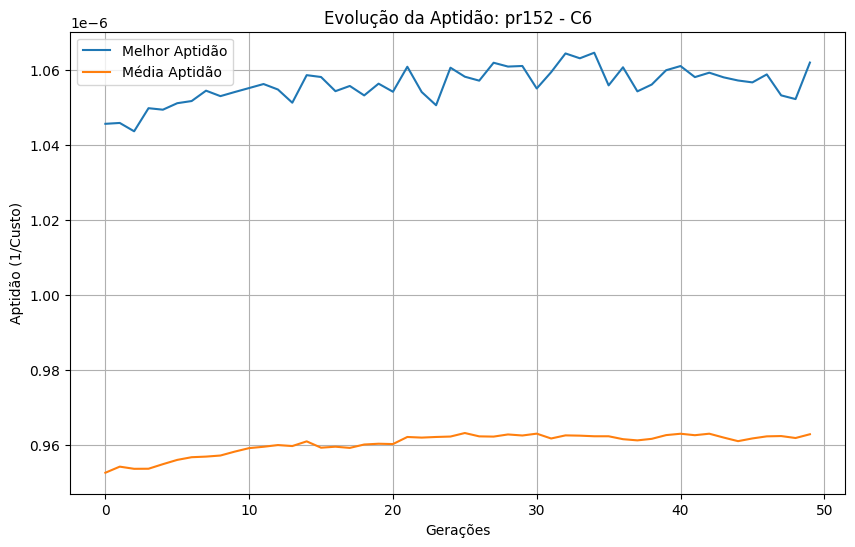

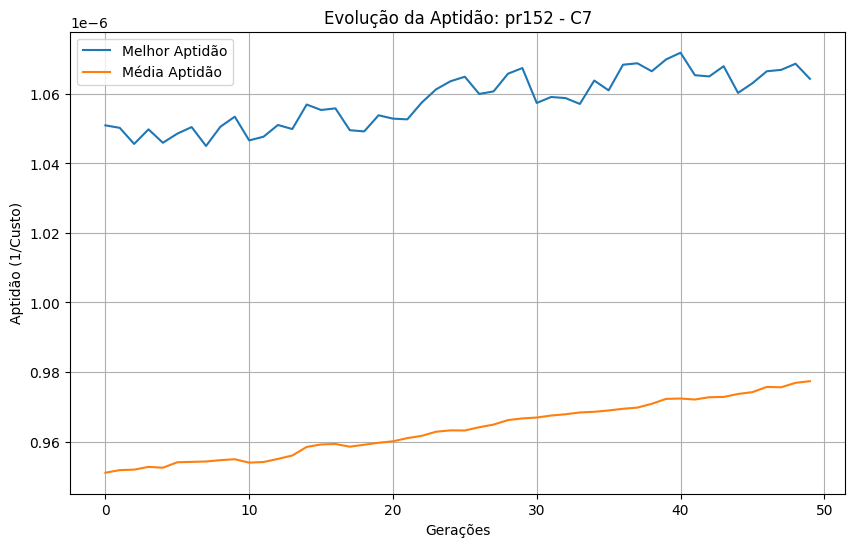

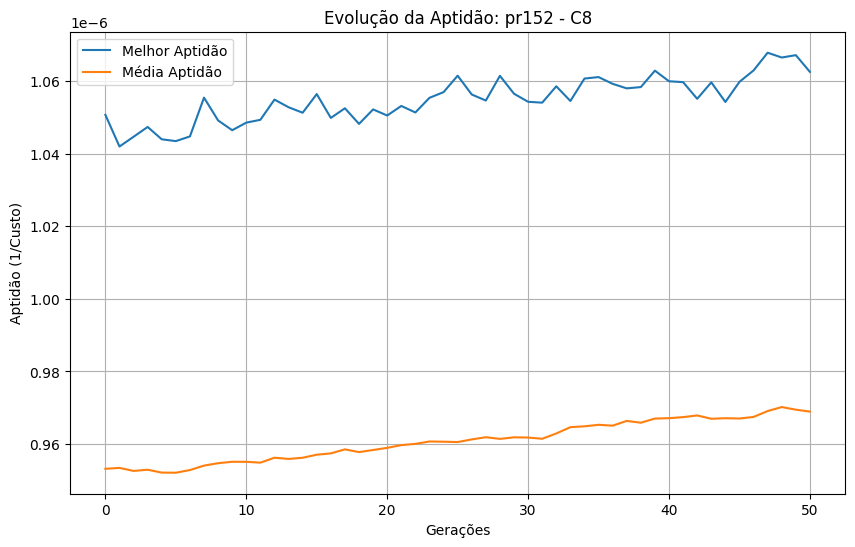

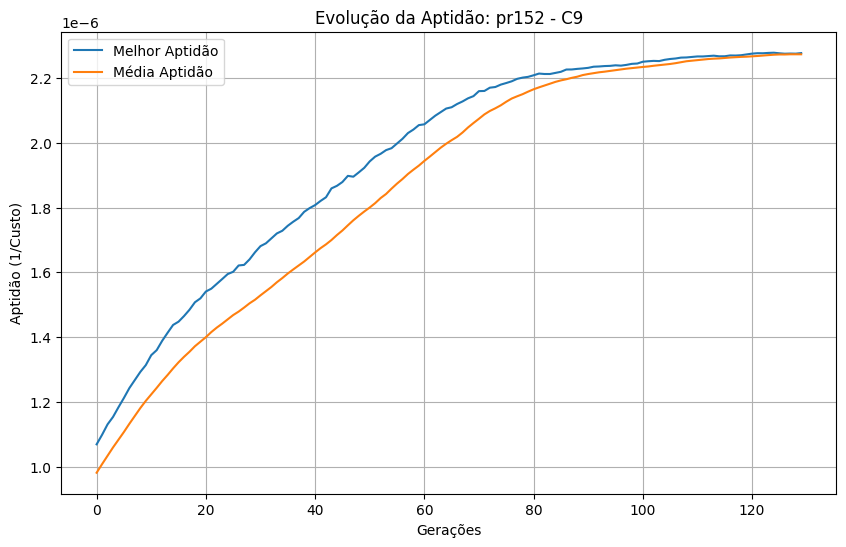

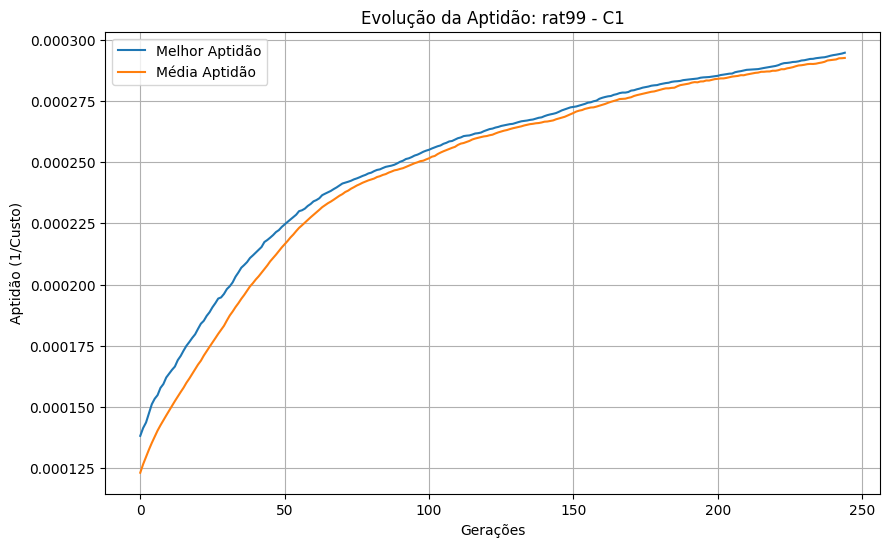

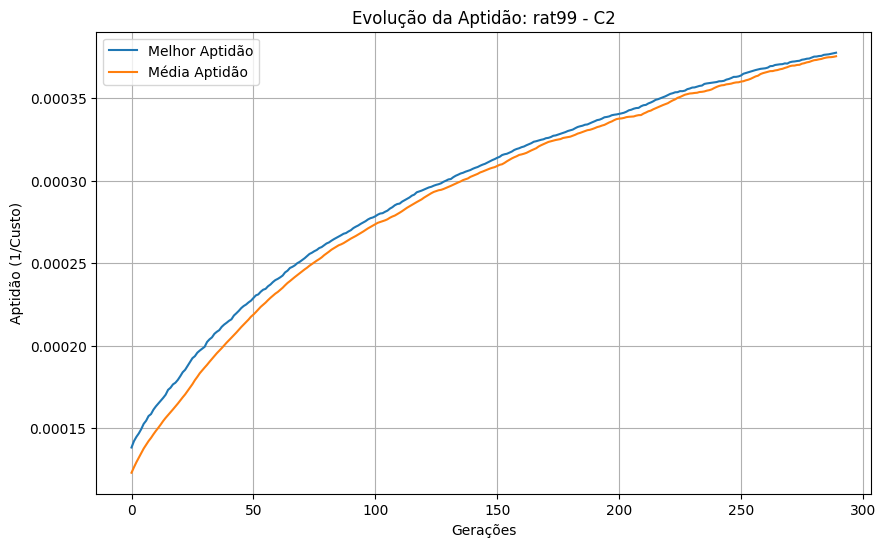

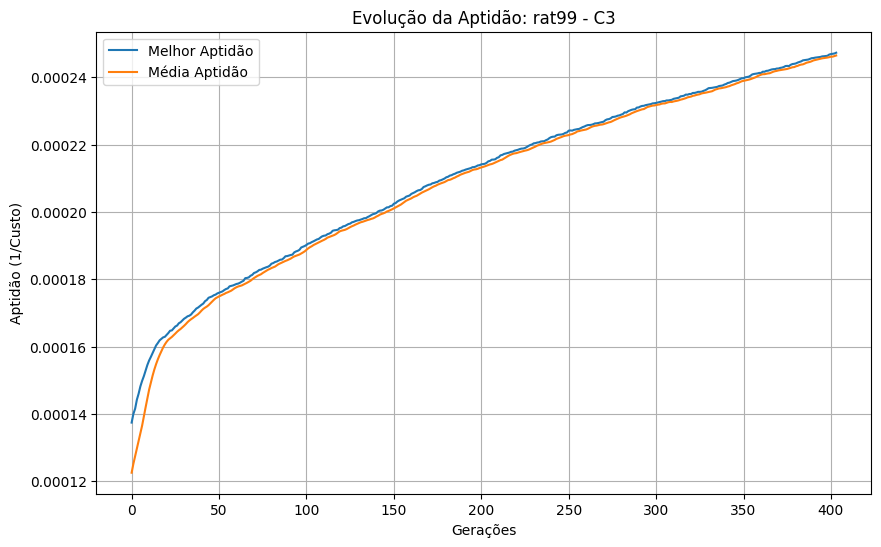

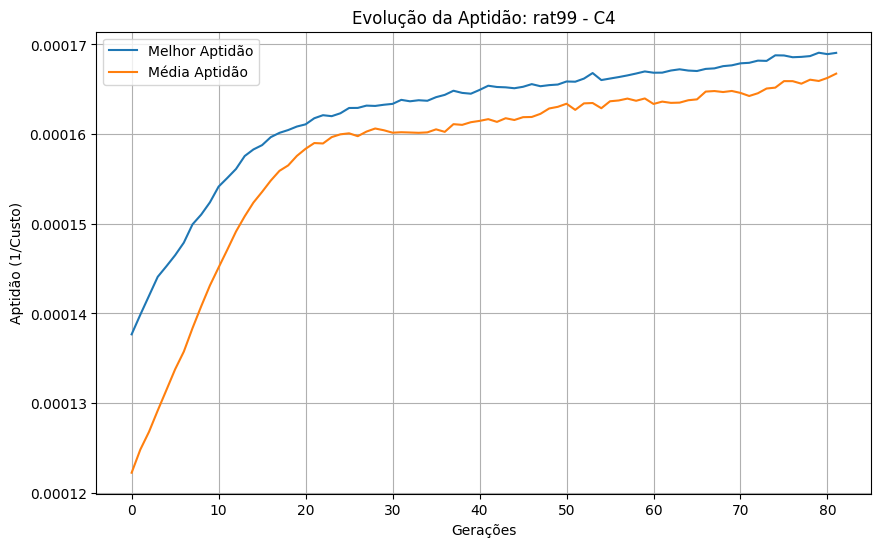

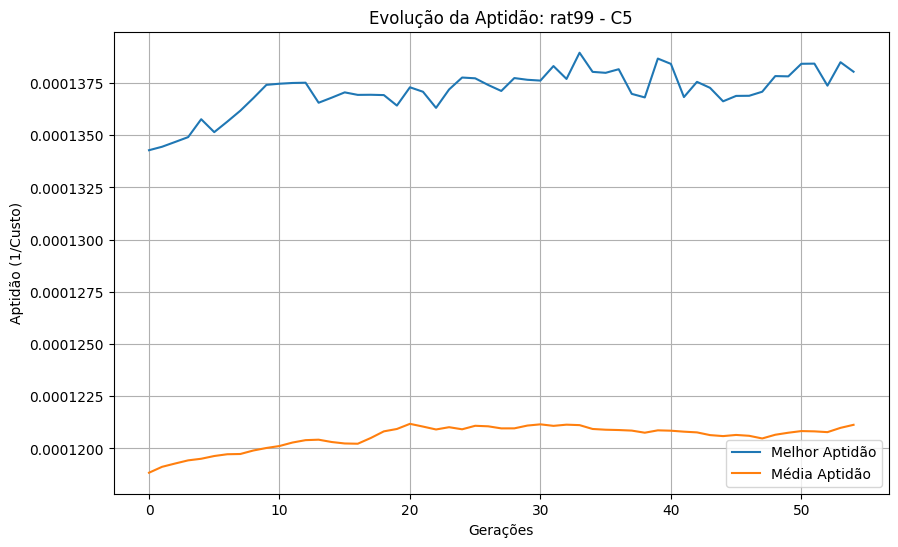

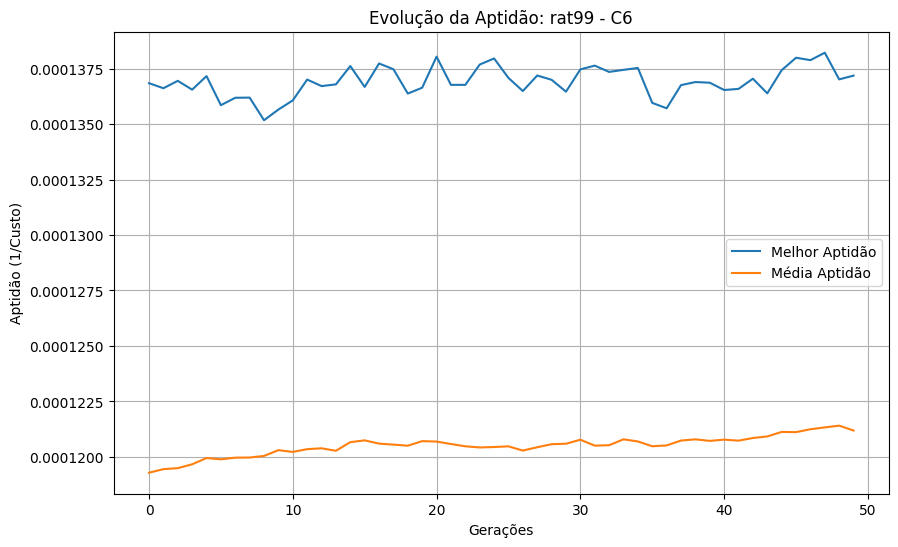

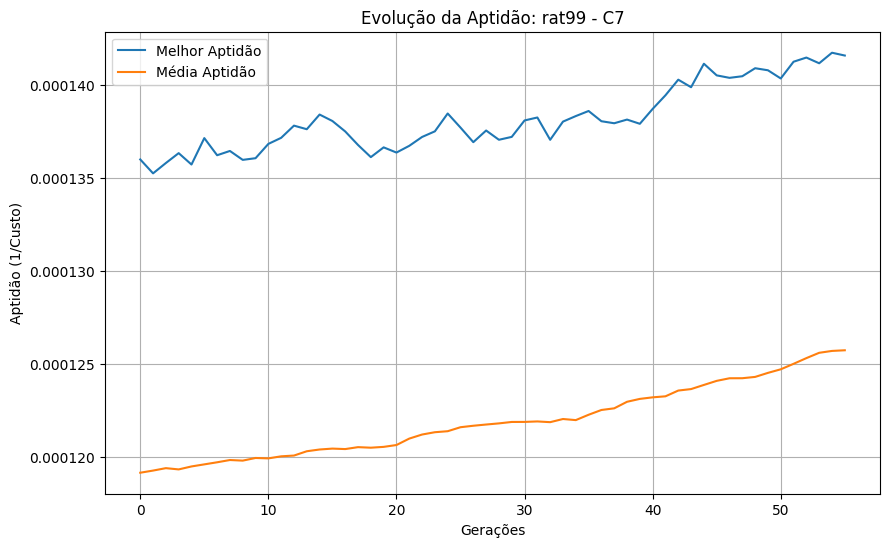

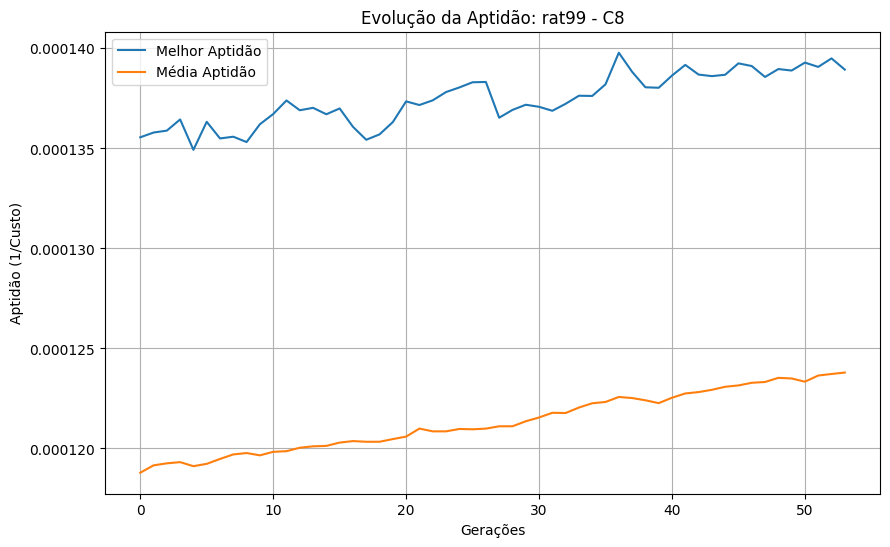

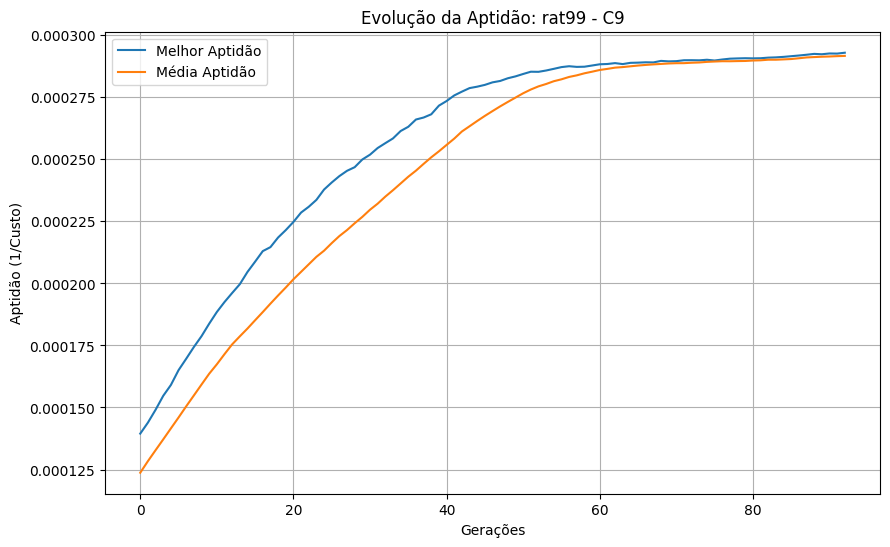

In [31]:
print_summary(results)

plot_convergence(results, "berlin52", "C1")
plot_convergence(results, "berlin52", "C2")
plot_convergence(results, "berlin52", "C3")
plot_convergence(results, "berlin52", "C4")
plot_convergence(results, "berlin52", "C5")
plot_convergence(results, "berlin52", "C6")
plot_convergence(results, "berlin52", "C7")
plot_convergence(results, "berlin52", "C8")
plot_convergence(results, "berlin52", "C9")

plot_convergence(results, "eil51", "C1")
plot_convergence(results, "eil51", "C2")
plot_convergence(results, "eil51", "C3")
plot_convergence(results, "eil51", "C4")
plot_convergence(results, "eil51", "C5")
plot_convergence(results, "eil51", "C6")
plot_convergence(results, "eil51", "C7")
plot_convergence(results, "eil51", "C8")
plot_convergence(results, "eil51", "C9")

plot_convergence(results, "pr152", "C1")
plot_convergence(results, "pr152", "C2")
plot_convergence(results, "pr152", "C3")
plot_convergence(results, "pr152", "C4")
plot_convergence(results, "pr152", "C5")
plot_convergence(results, "pr152", "C6")
plot_convergence(results, "pr152", "C7")
plot_convergence(results, "pr152", "C8")
plot_convergence(results, "pr152", "C9")

plot_convergence(results, "rat99", "C1")
plot_convergence(results, "rat99", "C2")
plot_convergence(results, "rat99", "C3")
plot_convergence(results, "rat99", "C4")
plot_convergence(results, "rat99", "C5")
plot_convergence(results, "rat99", "C6")
plot_convergence(results, "rat99", "C7")
plot_convergence(results, "rat99", "C8")
plot_convergence(results, "rat99", "C9")

In [27]:
def get_best_scenarios(results):
    best = {}

    for inst in results:
        best_scen = min(
            results[inst],
            key=lambda s: results[inst][s]['mean_best']
        )
        best[inst] = best_scen

    return best


best_scenarios = get_best_scenarios(results)

print("\n=== MELHOR CENÁRIO POR INSTÂNCIA ===")
for inst, scen in best_scenarios.items():
    print(f"{inst} -> {scen}")


=== MELHOR CENÁRIO POR INSTÂNCIA ===
berlin52 -> C9
eil51 -> C9
pr152 -> C9
rat99 -> C9


In [28]:
HYPERPARAMS = [
    {"pcross": 0.7, "pmut": 0.01},
    {"pcross": 0.8, "pmut": 0.02},
    {"pcross": 0.9, "pmut": 0.05},
]

In [29]:
for inst_name in instances:
    print(f"\n=== {inst_name} ===")

    scenario = SCENARIOS[best_scenarios[inst_name]]

    for cfg in HYPERPARAMS:
        costs = []

        for _ in range(30):
            _, best_cost, _ = genetic_algorithm_tsp(
                cities=instances[inst_name],
                fn_select=scenario['select'],
                fn_crossover=scenario['crossover'],
                fn_mutate=scenario['mutate'],
                pcross=cfg['pcross'],
                pmut=cfg['pmut'],
                pop_size=100
            )
            costs.append(best_cost)

        print(f"{cfg} -> mean={np.mean(costs):.2f}")


=== berlin52 ===
{'pcross': 0.7, 'pmut': 0.01} -> mean=12396.85
{'pcross': 0.8, 'pmut': 0.02} -> mean=11881.18
{'pcross': 0.9, 'pmut': 0.05} -> mean=10600.65

=== eil51 ===
{'pcross': 0.7, 'pmut': 0.01} -> mean=757.20
{'pcross': 0.8, 'pmut': 0.02} -> mean=677.22
{'pcross': 0.9, 'pmut': 0.05} -> mean=601.69

=== pr152 ===
{'pcross': 0.7, 'pmut': 0.01} -> mean=468059.54
{'pcross': 0.8, 'pmut': 0.02} -> mean=411321.90
{'pcross': 0.9, 'pmut': 0.05} -> mean=286292.42

=== rat99 ===
{'pcross': 0.7, 'pmut': 0.01} -> mean=3466.13
{'pcross': 0.8, 'pmut': 0.02} -> mean=3215.04
{'pcross': 0.9, 'pmut': 0.05} -> mean=2474.63


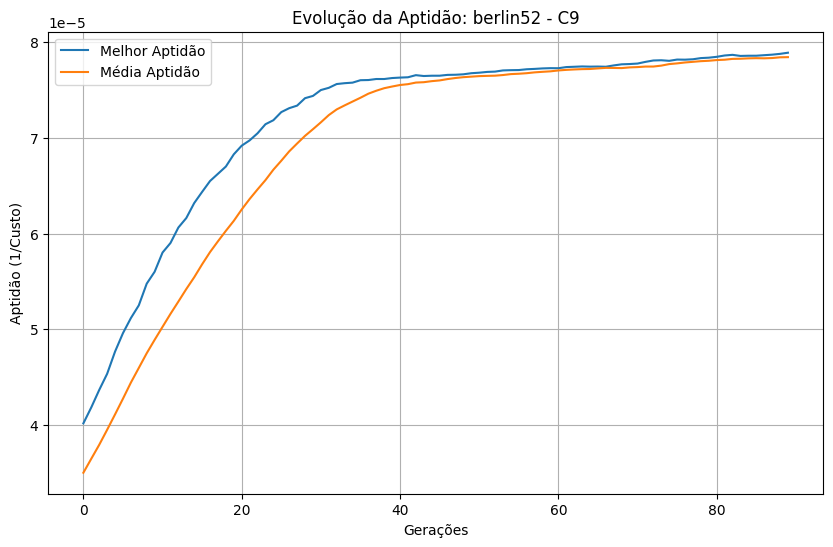

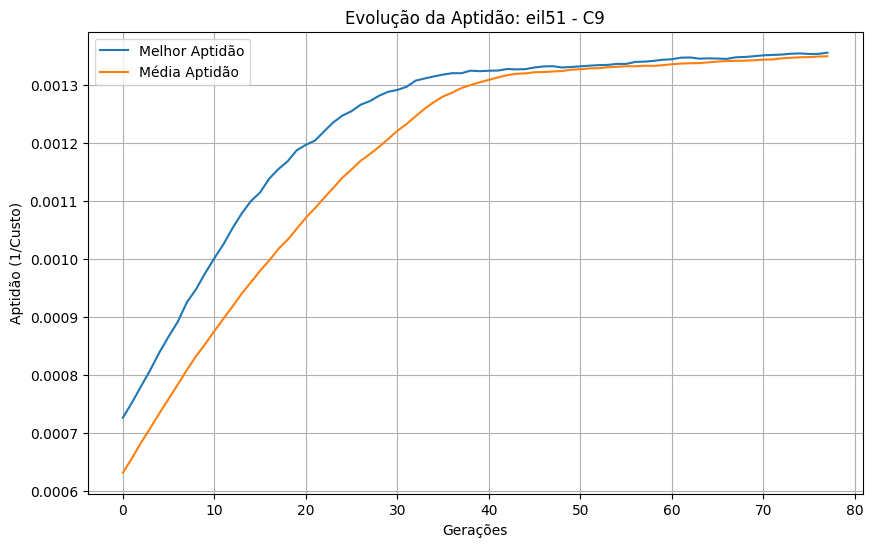

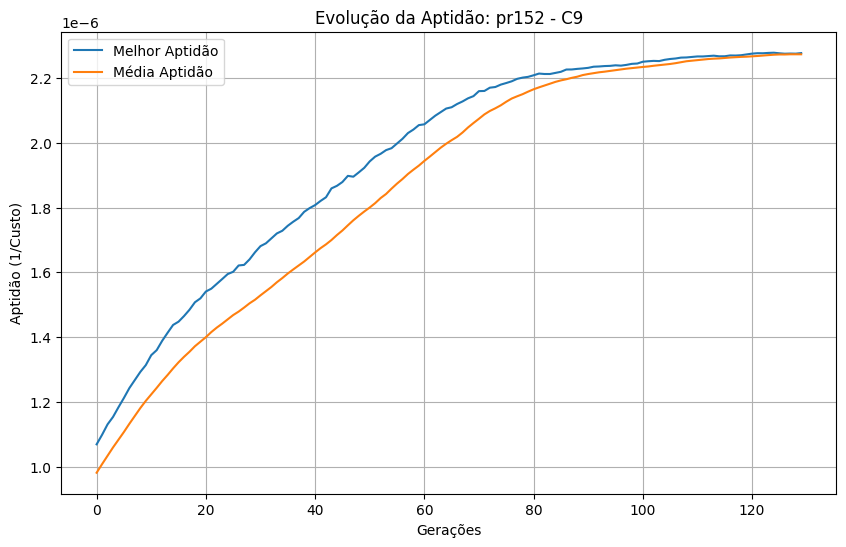

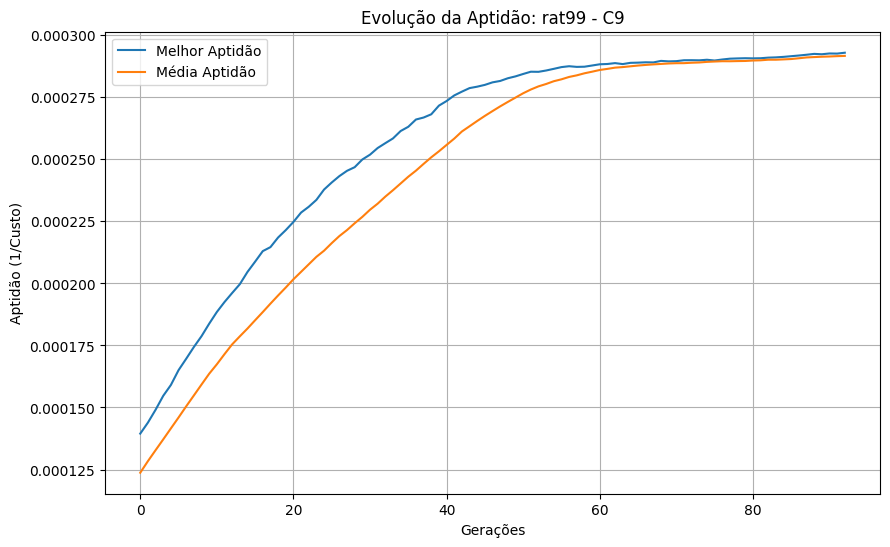

In [30]:
for inst in results:
    best = best_scenarios[inst]
    plot_convergence(results, inst, best)

## **7 CONCLUSÃO**

Neste trabalho, foi possível aplicar o Algoritmo Genético como uma abordagem heurística para a resolução do Problema do Caixeiro Viajante (TSP), evidenciando sua eficiência em lidar com problemas de alta complexidade combinatória. A modelagem adotada, baseada em representação por permutação e função de aptidão inversamente proporcional ao custo da rota, mostrou-se adequada para garantir a validade das soluções e direcionar o processo evolutivo.

Ao longo do desenvolvimento, observou-se que os operadores genéticos: seleção, cruzamento e mutação desempenham papel fundamental na exploração e exploração do espaço de busca. Em especial, a mutação contribuiu para a diversidade populacional, evitando a convergência prematura para ótimos locais, enquanto o cruzamento permitiu a combinação de boas características entre indivíduos.

Os experimentos realizados reforçam que a escolha dos hiperparâmetros, como taxa de mutação, tamanho da população e número de gerações, impacta diretamente na qualidade das soluções obtidas. Ajustes adequados desses parâmetros possibilitam alcançar rotas de menor custo em tempo computacional viável, mesmo sem garantir a optimalidade global.

Dessa forma, conclui-se que o Algoritmo Genético é uma ferramenta robusta e flexível para a resolução do TSP, especialmente em cenários onde métodos exatos são inviáveis. Como trabalhos futuros, sugere-se a investigação de operadores genéticos mais sofisticados, estratégias híbridas como a combinação com busca local e testes em instâncias maiores, visando melhorar ainda mais a qualidade das soluções e a eficiência do algoritmo.

## **REFERÊNCIAS**

- https://docs.google.com/document/d/e/2PACX-1vRhYtsvc5eOR2FWNCwaBiKL6suIOrxJig8LcSBbmCbyYsayia_DvPOOBlXZ4CAlQ5nlDD8kTaIDRwrN/pub
- https://en.wikipedia.org/wiki/MNIST_database
- http://yann.lecun.com/exdb/mnist/
- https://en.wikipedia.org/wiki/Anscombe%27s_quartet
- https://github.com/altair-viz/vega_datasets/blob/4f67bdaad10f45e3549984e17e1b3088c731503d/vega_datasets/_data/anscombe.json